In [1]:
RANDOM_STATE = 42

from pathlib import Path
import sys

BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

sys.path.insert(0, str(BASE_DIR))

# 04 — Avaliação Final

## Objetivo

Esta etapa avalia o modelo selecionado no conjunto de teste intocado, interpreta os erros e identifica as variáveis que mais contribuem para a previsão. O resultado final é conectado às implicações práticas do problema.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR, RANDOM_STATE
from src.models import build_models
from src.evaluation import permutation_importance_table

X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv")["high_quality"]
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv")["high_quality"]

model = build_models(RANDOM_STATE)["Random Forest"]
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## 1. Desempenho no conjunto de teste

As métricas são calculadas no conjunto de teste somente após a seleção do modelo. Isso fornece uma estimativa final do desempenho em dados que não participaram do treinamento ou da escolha do modelo.

In [3]:
final_metrics = pd.DataFrame([{
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
}])
display(final_metrics.round(4))
final_metrics.to_csv(METRICS_DIR / "random_forest_test_metrics.csv", index=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.9083,0.7619,0.5,0.6038,0.9124


### Interpretação

A avaliação final deve ser lida em conjunto com o desbalanceamento da classe positiva. Accuracy resume o acerto global, enquanto Precision, Recall e F1 tornam explícito o desempenho sobre High Quality. ROC-AUC complementa a análise ao medir a capacidade de separar as duas classes em diferentes limiares.

In [4]:
print(classification_report(y_test, y_pred, target_names=["Low/Medium Quality", "High Quality"], digits=4, zero_division=0))
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

                    precision    recall  f1-score   support

Low/Medium Quality     0.9231    0.9746    0.9481       197
      High Quality     0.7619    0.5000    0.6038        32

          accuracy                         0.9083       229
         macro avg     0.8425    0.7373    0.7760       229
      weighted avg     0.9006    0.9083    0.9000       229

Confusion matrix:
 [[192   5]
 [ 16  16]]


/mnt/data/tc02_final/notebooks/04_avaliacao.ipynb:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "\n",


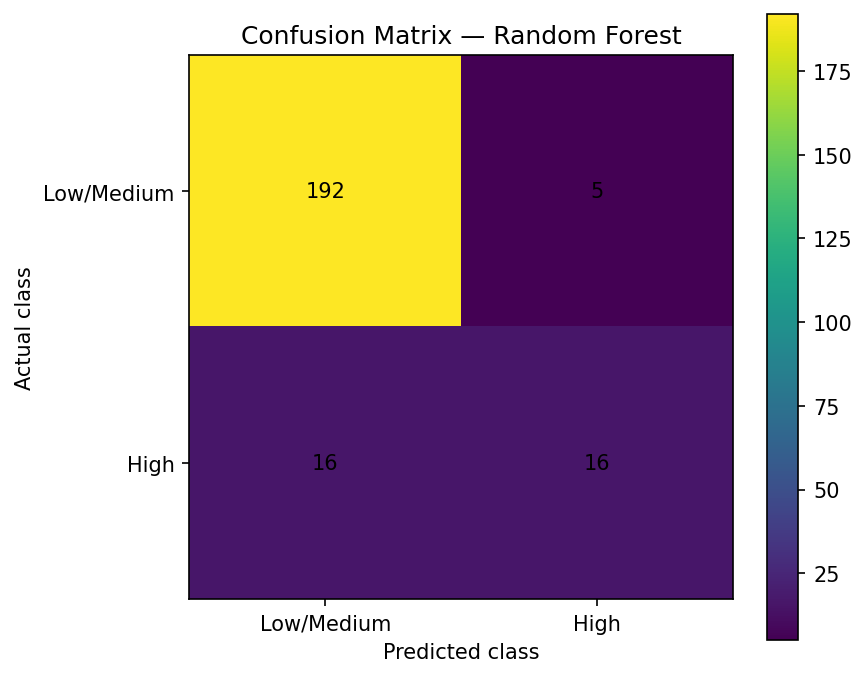

In [5]:
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.colorbar()
plt.xticks([0,1],["Low/Medium","High"])
plt.yticks([0,1],["Low/Medium","High"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_confusion_matrix_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação da matriz de confusão

A matriz separa acertos e erros entre as duas classes. No problema de negócio, um falso negativo representa um vinho que pertence à classe High Quality, mas não foi identificado pelo modelo. Esse erro é particularmente relevante porque representa uma oportunidade perdida de triagem de um produto potencialmente premium.

/mnt/data/tc02_final/notebooks/04_avaliacao.ipynb:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "execution_count": 1,


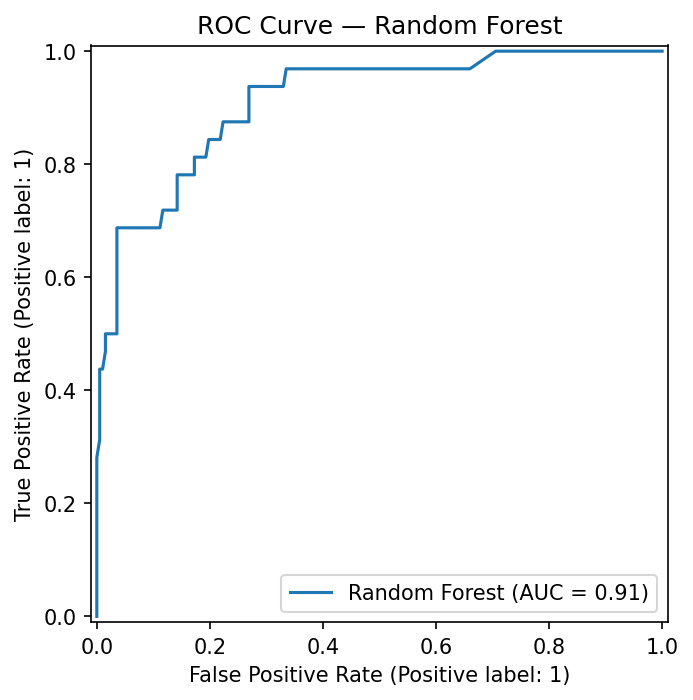

In [6]:
RocCurveDisplay.from_predictions(y_test, y_prob, name="Random Forest")
plt.title("ROC Curve — Random Forest")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_roc_curve_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação da curva ROC

A área sob a curva resume a capacidade do modelo de ordenar corretamente as duas classes. Uma AUC elevada indica que o modelo consegue separar High Quality de Low/Medium Quality com boa discriminação ao longo de diferentes limiares.

## 2. Feature importance

A permutation importance mede quanto o desempenho do F1 se deteriora quando a informação de uma variável é perturbada. Valores maiores indicam maior contribuição preditiva para o desempenho observado.

/mnt/data/tc02_final/notebooks/04_avaliacao.ipynb:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "import sys\n",


,Feature,Mean importance,Std importance
0,alcohol,0.3313,0.0791
1,volatile acidity,0.2727,0.0864
2,citric acid,0.2566,0.0714
3,sulphates,0.1588,0.0421
4,total sulfur dioxide,0.1458,0.0560
5,fixed acidity,0.0915,0.0351
6,density,0.0792,0.0437
7,pH,0.0670,0.0360
8,chlorides,0.0654,0.0486
9,free sulfur dioxide,0.0592,0.0267


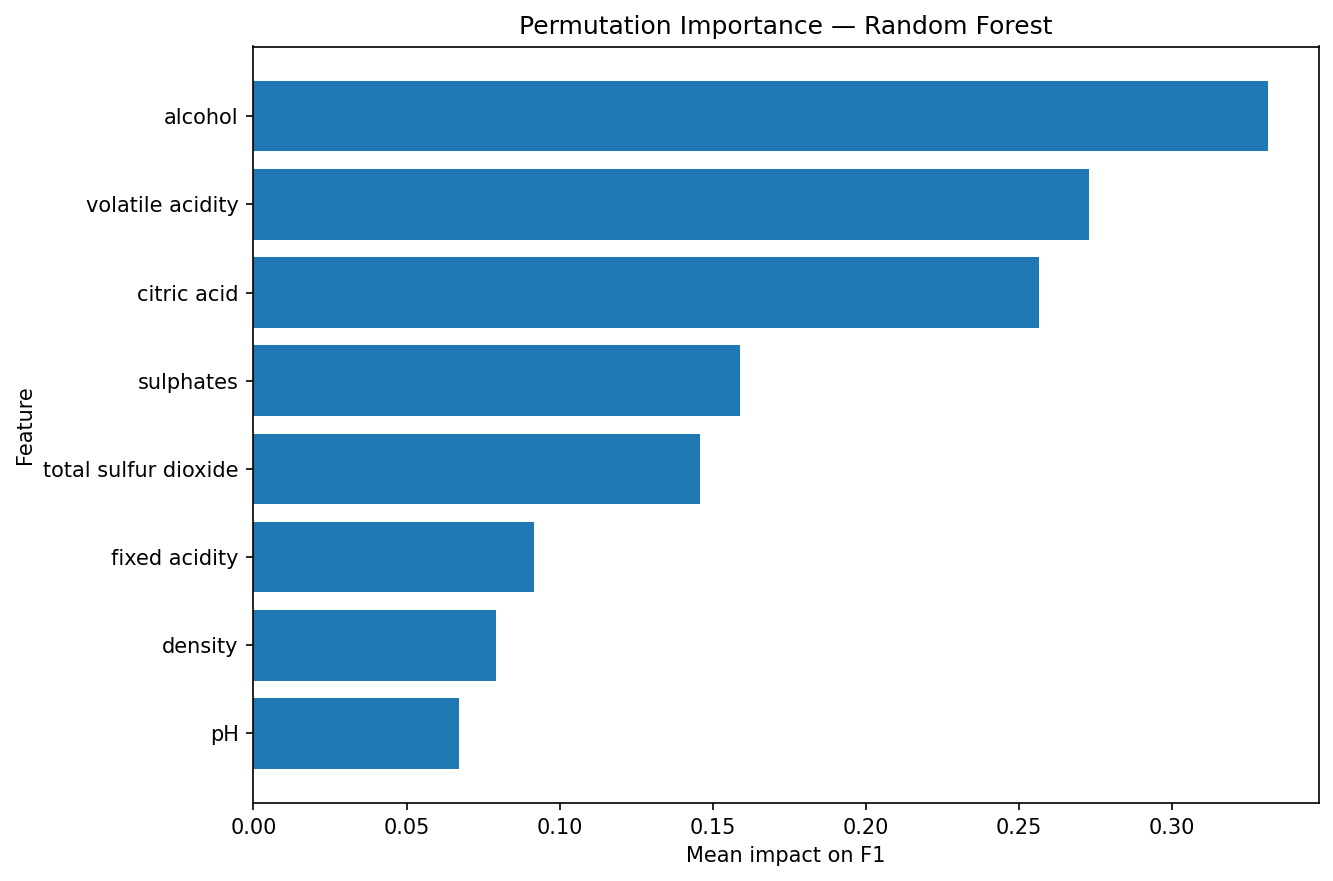

In [7]:
importance = permutation_importance_table(model, X_test, y_test, RANDOM_STATE)
display(importance.round(4))
importance.to_csv(METRICS_DIR / "random_forest_permutation_importance.csv", index=False)

plot_df = importance.head(8).sort_values("Mean importance")
plt.figure(figsize=(9,6))
plt.barh(plot_df["Feature"], plot_df["Mean importance"])
plt.title("Permutation Importance — Random Forest")
plt.xlabel("Mean impact on F1")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_permutation_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretação

`alcohol` aparece como o principal sinal preditivo, seguido por `volatile acidity`, `citric acid`, `sulphates` e `total sulfur dioxide`. Esses resultados representam contribuição preditiva dentro do dataset e não devem ser interpretados como evidência de causalidade.

## 3. Implicações práticas

Os resultados indicam que medições físico-químicas contêm sinal suficiente para apoiar uma camada de triagem de qualidade. Os principais indicadores identificados pelo modelo podem ser utilizados para priorizar amostras para inspeção adicional.

A proposta operacional é:

**physical-chemical measurements → predictive screening → prioritization → expert / sensory assessment**

O modelo deve complementar a análise sensorial, não substituí-la.

## 4. Limitações e próximos passos

- A classe High Quality representa apenas 13,91% da base.
- O modelo ainda deixa passar parte da classe positiva.
- A importância das variáveis é preditiva, não causal.
- A distribuição do dataset pode não representar todas as condições produtivas.
- Antes de adoção operacional, o modelo deve ser validado em novos dados de produção.
- Um próximo passo relevante é avaliar limiares de decisão conforme o custo de falsos negativos e falsos positivos.